# Definiendo umbrales de color para la segmentación del fondo

En este tutorial veremos cómo ajustar los umbrales de color para segmentar el fondo de las imágenes con `FruitExternalAnalyzer`.

Por defecto, `FruitExternalAnalyzer.generate_fruit_mask()` asume un fondo azul. Además, tiene umbrales preconfigurados para fondos blancos (`'white'`) y negros (`'black'`). Sin embargo, también es posible definir umbrales personalizados de forma manual. 

> Nota:
>  Aunque `FruitInternalAnalyzer` espera un fondo negro, la segmentación con fondos de otro color funciona exactamente de la misma manera que se muestra aquí.

In [1]:
# Session details
import traitly
from datetime import datetime

print(f"Traitly version used in this tutorial: {traitly.__version__}")
print(f"Run date: {datetime.now():%Y-%m-%d %H:%M}")

Traitly version used in this tutorial: 0.2.0
Run date: 2026-10-05 00:15


In [1]:
# Importar la clase External Analysis
from traitly.fruit_phenotyping import FruitExternalAnalyzer

Version de Traitly usada en este tutorial: 0.2.0


## Fondo azul

Primero, cargamos la clase `FruitExternalAnalyzer` de la librería `traitly` y la imagen que queremos analizar. Como la imagen incluye una tira de referencia de tamaño, corremos `setup_measurements()` para detectar su posición y excluir esa zona de las máscaras de frutos.

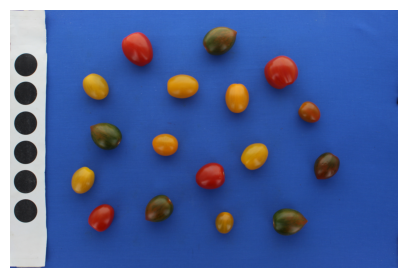

In [2]:
path = './Test_10.png'
blue_example = FruitExternalAnalyzer(path)
blue_example.load_image()
blue_example.setup_measurements(verbose = False)

Como el **azul** es el color por defecto, no es necesario pasar ningún argumento adicional a `generate_fruit_mask()` para esta imagen.

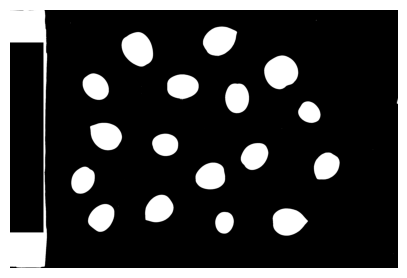

In [3]:
blue_example.generate_fruit_mask()

Podemos verificar el número de contornos detectados y su ubicación con `plot=True` en `detect_fruits()`.

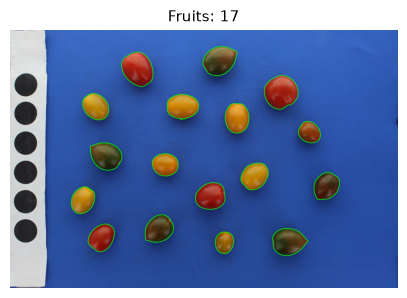


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_fruit_area: 1000


In [4]:
blue_example.detect_fruits(plot = True, contour_thickness = 8)

## Fondo gris

En este segundo ejemplo tenemos una imagen con fondo gris. Como el gris no es un color preconfigurado, definiremos **umbrales HSV personalizados** de forma manual. Para esto, podemos usar `generate_color_scatterplot()`, que muestra los colores de los píxeles de la imagen (10,000 por defecto) en el espacio HSV. Cada punto en los gráficos representa un píxel, coloreado con su valor **RGB** real. El objetivo es encontrar el rango [H,S,V] en el que caen los píxeles del fondo gris.

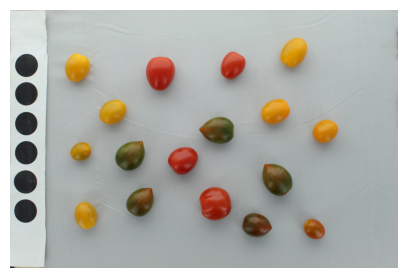

In [5]:
path = './Test_27.png'
gray_example = FruitExternalAnalyzer(path)
gray_example.load_image()
gray_example.setup_measurements(verbose = False)

En este caso, los gráficos **H vs S** y **S vs V** son los más informativos:

- En **H vs S**, se puede ver que los píxeles grises se distribuyen en todo el rango de matiz (H) de 0 a 180 (círculo naranja), y que la mayoría tiene un valor de saturación (S) menor a 50 (línea azul punteada).
- El gráfico **S vs V** confirma que los píxeles del fondo se agrupan en un rango de brillo (V) de 60 a 255 (línea morada punteada) y una saturación (S) de 0 a 50 (línea azul punteada).

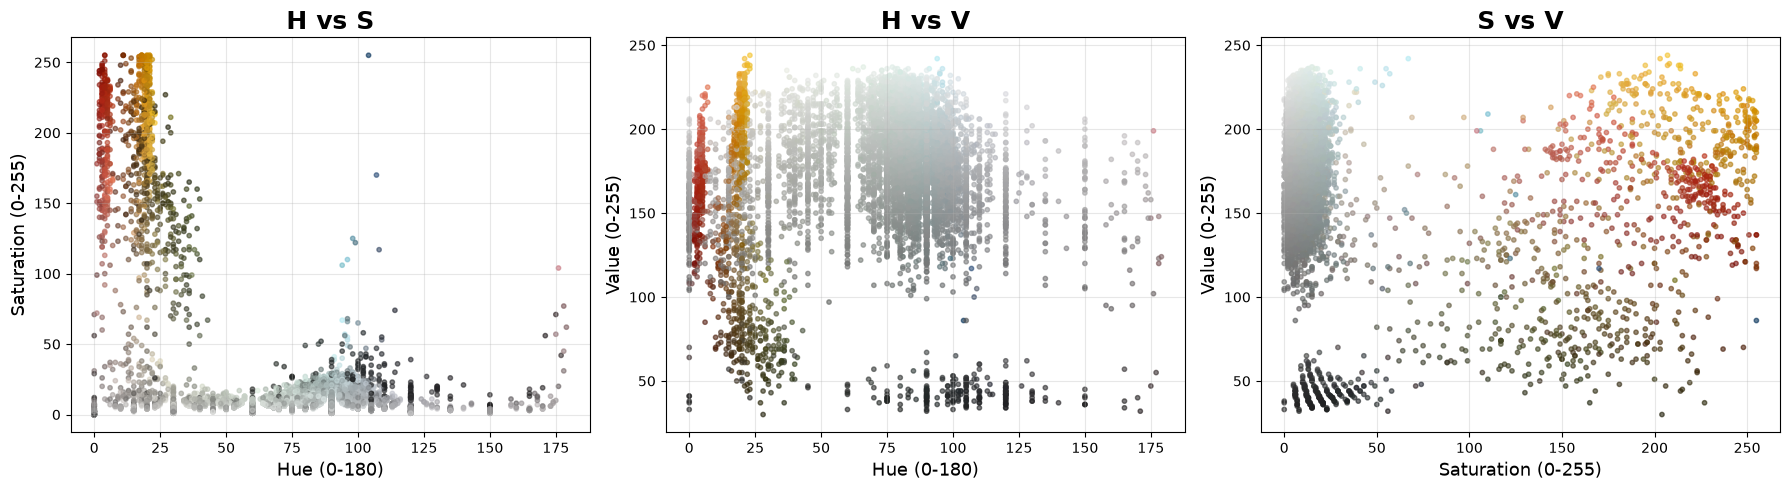

In [6]:
gray_example.generate_color_scatterplot()

A partir de esto, definimos `lower_color` y `upper_color`, donde cada valor sigue el formato `[H,S,V]`, y los pasamos directamente a `generate_fruit_mask()`.

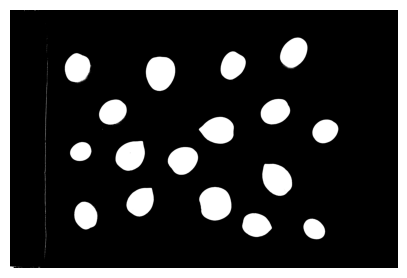

In [7]:
# hsv_threshold = [H, S, V]
lower_color = [0, 0, 60]
upper_color = [180, 50, 255]

gray_example.generate_fruit_mask(lower_hsv = lower_color, 
                                 upper_hsv = upper_color)

Verificamos con `detect_fruits()` que los frutos quedaron correctamente segmentados. En este caso, como algunos frutos eran menos circulares que los del ejemplo anterior, redujimos ligeramente el umbral de circularidad de 0.5 (valor por defecto) a 0.3.

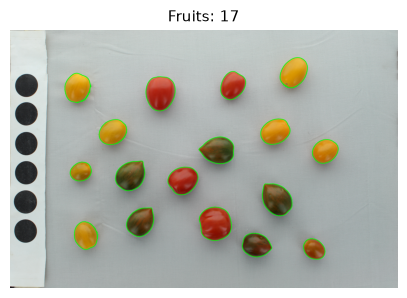


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.3
        - min_fruit_area: 1000


In [8]:
gray_example.detect_fruits(plot = True, 
                           contour_thickness = 8, 
                           min_fruit_circularity = 0.3)

## Fondo blanco

Por último, tenemos un ejemplo con fondo blanco. Como `white` es un color preconfigurado, simplemente usamos `background_color='white'` en `generate_fruit_mask()`.

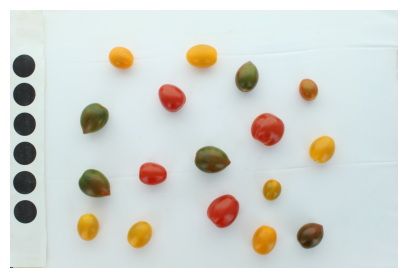

In [9]:
path = './Test_56.png'
white_example = FruitExternalAnalyzer(path)
white_example.load_image()
white_example.setup_measurements(verbose = False)

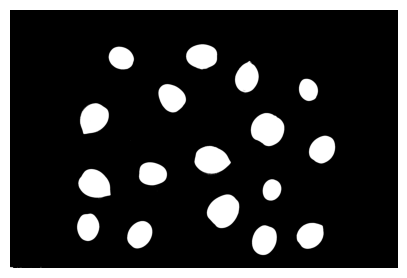

In [10]:
white_example.generate_fruit_mask(background_color = 'white')

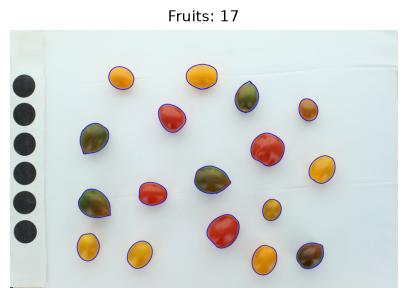


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.3
        - min_fruit_area: 1000


In [11]:
white_example.detect_fruits(plot = True, 
                            contour_thickness = 8, 
                            contour_color = (0,0,220), 
                            min_fruit_circularity = 0.3)